# Products Profiling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/olist_products_dataset.csv')
print('Rows, Cols:', df.shape)
df.dtypes

Rows, Cols: (32951, 9)


product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

In [2]:
df.head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57.0,163.0,1.0,400.0,27.0,13.0,17.0
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36.0,1156.0,1.0,600.0,17.0,10.0,12.0


In [3]:
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
pd.DataFrame({'Count': missing, 'Pct': missing_pct}).sort_values(by='Count', ascending=False)

,Count,Pct
product_category_name,610,1.851234
product_description_lenght,610,1.851234
product_name_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_height_cm,2,0.006070
product_length_cm,2,0.006070
product_width_cm,2,0.006070
product_id,0,0.000000


In [4]:
print('Full row duplicates:', df.duplicated().sum())

Full row duplicates: 0


In [5]:
print('product_id duplicates:', df['product_id'].duplicated().sum())

product_id duplicates: 0


Missing category %: 1.8512336499650999


<Axes: title={'center': 'Top Categories'}, xlabel='product_category_name'>

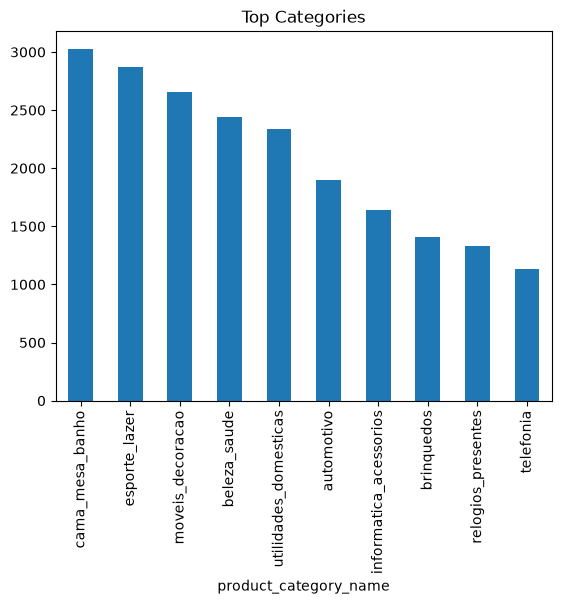

In [6]:
print('Missing category %:', df['product_category_name'].isnull().mean() * 100)
df['product_category_name'].value_counts().head(10).plot(kind='bar', title='Top Categories')

In [7]:
dim_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in dim_cols:
    print(f'{col} zeros:', (df[col] == 0).sum())

product_weight_g zeros: 4
product_length_cm zeros: 0
product_height_cm zeros: 0
product_width_cm zeros: 0


### Takeaways
- `product_id` is unique with no duplicates, but ~1.8% of products are missing a category name.
- Some products have zero-values for weight (4 items), which is likely a data entry error.
- Note: `product_name_lenght` and `product_description_lenght` retain their original typos to prevent merge issues.